# Réalisation du plan d'expérience de l'algorithme Génétique

Ce plan d'expérience suivra ce plan : 
- Définition des paramètres globaux
- Étude de trajectoire
- Étude de l'influence des paramètres
- Définition des paramètres optimisés

## Définition des paramètres globaux

Nous allons réaliser l'étude statistiques sur les paramètres suivants:
- $N= \{10, 12, 15, 17, 20, 22, 25, 30\}$ : nombre de sommets
- $i= 50$ : nombre d'itérations (générations) par instance

L'objectif est d'itérer sur les mêmes graphes. Nous utilisons donc des `seed` pour chaque instance de graphe $N$.
Nous allons ensuite calculer la borne de chaque graphe. Cela nous permettra de calculer le `gap` pour comparer équitablement les algorithmes entre eux

### Résultats

Chaque algorithme doit avoir en sortie: 
- le meilleur coût des itération
- la moyenne des coûts
- la médiane des coûts
- l'écart-type
- le minimun et le maximum
- graphiques:
    - Trajectoire
    - influence de chaque paramètre (Heatmap à double entrée (type github)) -> tendance générale
    - Distance à la borne (`gap`)
- Meilleur paramètres

In [19]:
import sys

import numpy as np
import networkx as nx

sys.path.insert(0, "../../")
sys.path.insert(0, "../")

from graph_generator import generate_graph
from helper import PENALTY_COST
from src.algorithms.genetic import resolve_by_genetic


### Paramètres globaux et génération des instances

- `N_VALUES` : tailles de graphe étudiées
- `NB_SEEDS` : nombre d'instances (seed distinct) par taille — pour itérer sur les mêmes graphes
- `NB_GENERATIONS` : nombre de générations de l'algorithme par instance

In [20]:
N_VALUES: list[int] = [10, 12, 15, 17, 20, 22, 25, 30]
NB_SEEDS: int = 10
NB_GENERATIONS: int = 50


def get_standard_instances(n: int, nb_seeds: int = NB_SEEDS) -> list[tuple[int, nx.Graph]]:
    """Génère `nb_seeds` graphes reproductibles de taille `n`, un par seed."""
    instances: list[tuple[int, nx.Graph]] = []
    for seed in range(nb_seeds):
        np.random.seed(seed)
        graph = generate_graph(n)
        instances.append((seed, graph))
    return instances


### Borne de référence et gap

Borne inférieure « min-sortants » pour toutes les tailles : $\frac{1}{2} \sum_v \min_{u \neq v} w(v,u)$, arêtes interdites ($w = -1$) exclues.

$$\text{gap} = 100 \times \frac{\text{cost} - \text{reference}}{\text{reference}}$$

In [21]:
def lower_bound_min_outgoing(graph: nx.Graph) -> float:
    """Borne inférieure : demi-somme des arêtes sortantes minimales (arêtes interdites exclues)."""
    total: float = 0.0
    for v in graph.nodes():
        min_edge: float = float("inf")
        for u in graph.nodes():
            if u == v:
                continue
            w: float = graph.edges[v, u]["weight"]
            if w == -1:
                continue
            if w < min_edge:
                min_edge = w
        if min_edge != float("inf"):
            total += min_edge
    return total / 2.0


def reference_value(graph: nx.Graph) -> float:
    """Borne inférieure de référence pour le calcul du gap."""
    return lower_bound_min_outgoing(graph)


def compute_gap(cost: float, reference: float) -> float:
    """Gap en %, NaN si `reference <= 0` ou si aucune solution valide (coût >= PENALTY_COST)."""
    if cost >= PENALTY_COST or reference <= 0:
        return float("nan")
    return 100.0 * (cost - reference) / reference

### Pré-calcul des instances et bornes

On matérialise `instances[n]` = liste de `(seed, graph, reference)` pour réutiliser les mêmes graphes + bornes dans toutes les études suivantes.

In [22]:
instances: dict[int, list[tuple[int, nx.Graph, float]]] = {}

for n in N_VALUES:
    raw: list[tuple[int, nx.Graph]] = get_standard_instances(n)
    enriched: list[tuple[int, nx.Graph, float]] = []
    for seed, graph in raw:
        ref: float = reference_value(graph)
        enriched.append((seed, graph, ref))
    instances[n] = enriched
    refs: list[float] = [r for _, _, r in enriched]
    print(f"N={n:3d} | {len(enriched)} instances | ref min={min(refs):.2f} max={max(refs):.2f}")


N= 10 | 10 instances | ref min=8.10 max=18.52
N= 12 | 10 instances | ref min=8.10 max=20.10
N= 15 | 10 instances | ref min=7.65 max=17.25
N= 17 | 10 instances | ref min=7.05 max=16.80
N= 20 | 10 instances | ref min=7.58 max=16.87
N= 22 | 10 instances | ref min=5.40 max=15.07
N= 25 | 10 instances | ref min=6.38 max=15.90
N= 30 | 10 instances | ref min=7.65 max=12.30


## Étude de trajectoire

On exécute l'algorithme génétique sur une instance de référence (N=20, seed=0) en enregistrant le meilleur coût à chaque génération pour visualiser la convergence.

Paramètres utilisés :
- `population_size` : taille de la population
- `generations` : nombre de générations
- `crossover_rate` : probabilité de croisement (OX)
- `mutation_rate` : probabilité de mutation (swap)
- `tournament_size` : taille du tournoi de sélection
- `elite_size` : nombre d'individus élites conservés sans modification

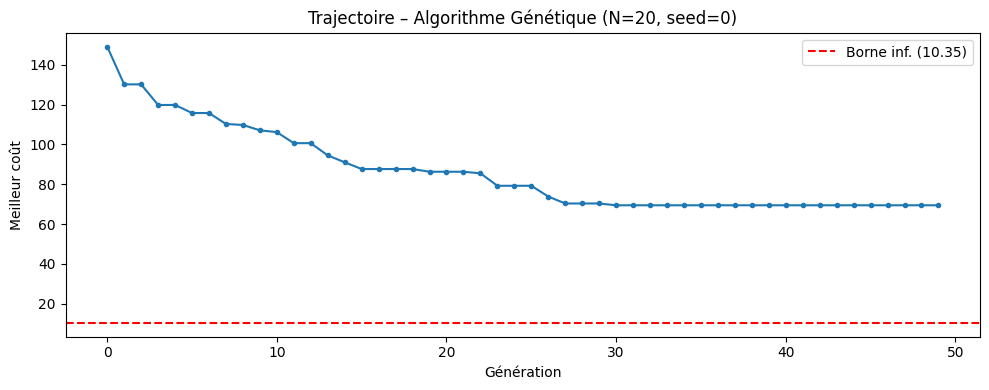

In [31]:
import random
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from helper import calculate_tour_cost_with_penalty


def _generate_random_individual(nodes: list[int]) -> list[int]:
    individual = nodes.copy()
    random.shuffle(individual)
    return individual


def _ordered_crossover(parent1: list[int], parent2: list[int]) -> list[int]:
    size = len(parent1)
    start, end = sorted(random.sample(range(size), 2))
    child = [-1] * size
    child[start : end + 1] = parent1[start : end + 1]
    pointer = end + 1
    for gene in parent2[end + 1 :] + parent2[: end + 1]:
        if gene not in child:
            if pointer >= size:
                pointer = 0
            child[pointer] = gene
            pointer += 1
    return child


def _swap_mutation(individual: list[int], mutation_rate: float) -> list[int]:
    if random.random() < mutation_rate:
        i, j = random.sample(range(len(individual)), 2)
        individual[i], individual[j] = individual[j], individual[i]
    return individual


def _tournament_selection(
    population: list[list[int]], costs: list[float], tournament_size: int
) -> list[int]:
    participants = random.sample(list(zip(population, costs)), tournament_size)
    participants.sort(key=lambda item: item[1])
    return participants[0][0].copy()


def genetic_trajectory(
    graph: nx.Graph,
    population_size: int = 50,
    generations: int = NB_GENERATIONS,
    crossover_rate: float = 0.8,
    mutation_rate: float = 0.2,
    tournament_size: int = 3,
    elite_size: int = 2,
) -> list[float]:
    """Exécute l'algorithme génétique et retourne la trajectoire du meilleur coût par génération."""
    nodes: list[int] = list(graph.nodes())
    population = [_generate_random_individual(nodes) for _ in range(population_size)]
    best_cost: float = float("inf")
    trajectory: list[float] = []

    for _ in range(generations):
        costs = [calculate_tour_cost_with_penalty(graph, ind) for ind in population]

        for ind, cost in zip(population, costs):
            if cost < best_cost:
                best_cost = cost

        trajectory.append(best_cost)

        sorted_pop = [ind for _, ind in sorted(zip(costs, population), key=lambda x: x[0])]
        new_population: list[list[int]] = sorted_pop[:elite_size]

        while len(new_population) < population_size:
            p1 = _tournament_selection(population, costs, tournament_size)
            p2 = _tournament_selection(population, costs, tournament_size)
            child = _ordered_crossover(p1, p2) if random.random() < crossover_rate else p1.copy()
            child = _swap_mutation(child, mutation_rate)
            new_population.append(child)

        population = new_population

    return trajectory


# Instance de référence : N=20, seed=0
_, ref_graph, ref_lb = instances[20][0]
traj = genetic_trajectory(ref_graph, generations=NB_GENERATIONS)

plt.figure(figsize=(10, 4))
plt.plot(traj, marker="o", markersize=3, linewidth=1.5)
plt.axhline(ref_lb, color="red", linestyle="--", label=f"Borne inf. ({ref_lb:.2f})")
plt.xlabel("Génération")
plt.ylabel("Meilleur coût")
plt.title("Trajectoire – Algorithme Génétique (N=20, seed=0)")
plt.legend()
plt.tight_layout()
plt.show()


## Étude de l'influence des paramètres

On fait varier les cinq paramètres de l'algorithme génétique :
- `population_size` $\in \{10, 20, 50, 100, 200\}$
- `crossover_rate` $\in \{0.5, 0.6, 0.7, 0.8, 0.9, 1.0\}$
- `mutation_rate` $\in \{0.05, 0.1, 0.2, 0.3, 0.5\}$
- `tournament_size` $\in \{2, 3, 5, 7\}$
- `elite_size` $\in \{0, 1, 2, 5\}$

**Deux études complémentaires :**
1. **OAT (One-At-a-Time)** : un paramètre varie, les autres fixés aux valeurs par défaut, sur l'ensemble des instances → sensibilité marginale de chaque paramètre.
2. **Grille complète** (instance N=20, seed=0) : exhaustif sur toutes les combinaisons → meilleure configuration globale + heatmaps croisées.

In [32]:
import itertools
import pandas as pd

PARAM_GRID: dict[str, list] = {
    "population_size": [5, 10, 20, 50, 100, 200, 500],
    "crossover_rate":  [0.0, 0.3, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 1.0],
    "mutation_rate":   [0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 0.8, 1.0],
    "tournament_size": [2, 3, 4, 5, 7, 10],
    "elite_size":      [0, 1, 2, 3, 5, 10],
}

DEFAULT_PARAMS: dict = {
    "population_size": 50,
    "crossover_rate":  0.8,
    "mutation_rate":   0.2,
    "tournament_size": 3,
    "elite_size":      2,
}

# OAT : un paramètre varie, les autres fixés aux valeurs par défaut
oat_results: dict[str, dict] = {}

for param_name, values in PARAM_GRID.items():
    oat_results[param_name] = {}
    for val in values:
        params = DEFAULT_PARAMS.copy()
        params[param_name] = val
        gaps: list[float] = []
        for n in N_VALUES:
            for seed, graph, ref in instances[n]:
                _, cost = resolve_by_genetic(graph, generations=NB_GENERATIONS, **params)
                gap = compute_gap(cost, ref)
                if not np.isnan(gap):
                    gaps.append(gap)
        oat_results[param_name][val] = np.mean(gaps) if gaps else float("nan")
        print(f"{param_name}={str(val):>6} | gap moyen={oat_results[param_name][val]:.2f}%")
    print()

population_size=     5 | gap moyen=1129.05%
population_size=    10 | gap moyen=877.00%
population_size=    20 | gap moyen=745.29%
population_size=    50 | gap moyen=578.38%
population_size=   100 | gap moyen=529.27%
population_size=   200 | gap moyen=515.21%
population_size=   500 | gap moyen=545.53%

crossover_rate=   0.0 | gap moyen=673.37%
crossover_rate=   0.3 | gap moyen=612.16%
crossover_rate=   0.5 | gap moyen=591.00%
crossover_rate=   0.6 | gap moyen=586.36%
crossover_rate=   0.7 | gap moyen=607.15%
crossover_rate=   0.8 | gap moyen=589.12%
crossover_rate=   0.9 | gap moyen=593.90%
crossover_rate=  0.95 | gap moyen=597.48%
crossover_rate=   1.0 | gap moyen=614.26%

mutation_rate=  0.01 | gap moyen=798.83%
mutation_rate=  0.05 | gap moyen=697.13%
mutation_rate=   0.1 | gap moyen=643.20%
mutation_rate=   0.2 | gap moyen=615.11%
mutation_rate=   0.3 | gap moyen=592.20%
mutation_rate=   0.5 | gap moyen=606.82%
mutation_rate=   0.8 | gap moyen=661.02%
mutation_rate=   1.0 | gap moye

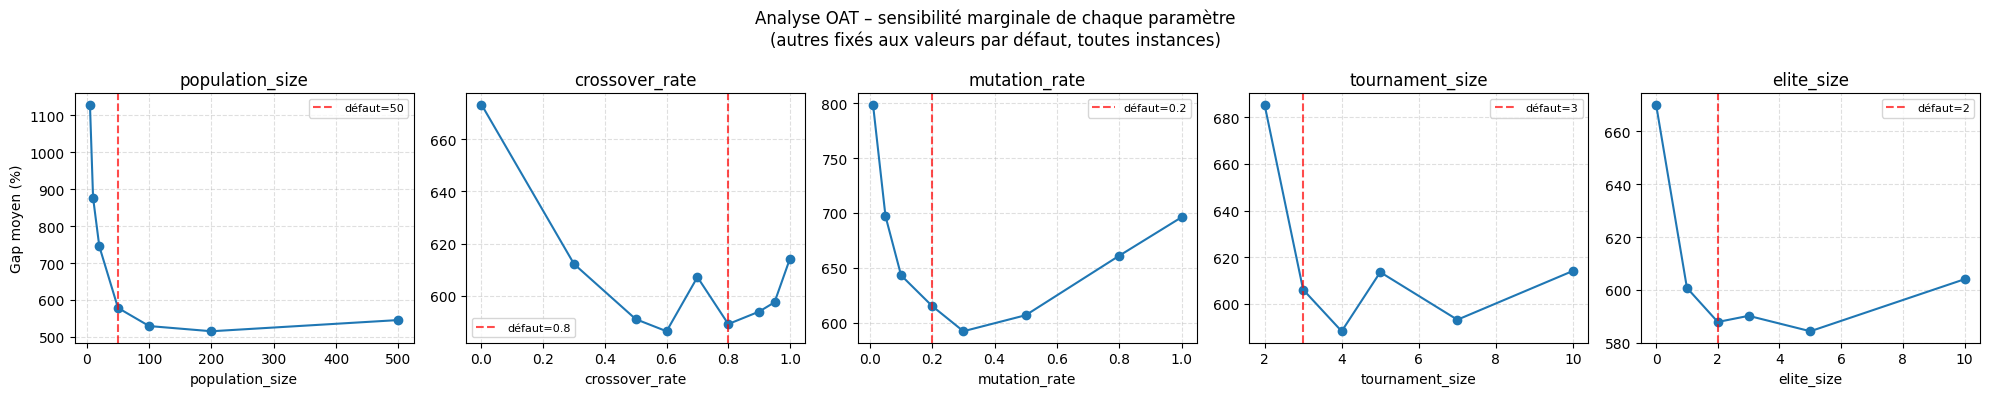

In [33]:
fig, axes = plt.subplots(1, len(PARAM_GRID), figsize=(20, 4))

for ax, (param_name, val_gaps) in zip(axes, oat_results.items()):
    values      = list(val_gaps.keys())
    gaps        = list(val_gaps.values())
    default_val = DEFAULT_PARAMS[param_name]

    ax.plot(values, gaps, marker="o", linewidth=1.5)
    ax.axvline(default_val, color="red", linestyle="--", alpha=0.7, label=f"défaut={default_val}")
    ax.set_title(param_name)
    ax.set_xlabel(param_name)
    ax.set_ylabel("Gap moyen (%)" if ax is axes[0] else "")
    ax.legend(fontsize=8)
    ax.grid(True, linestyle="--", alpha=0.4)

plt.suptitle("Analyse OAT – sensibilité marginale de chaque paramètre\n(autres fixés aux valeurs par défaut, toutes instances)")
plt.tight_layout()
plt.show()

In [34]:
_, grid_graph, grid_ref = instances[20][0]

GRID_POP: list[int]   = [20, 50, 100, 200]
GRID_CR:  list[float] = [0.6, 0.8, 1.0]
GRID_MR:  list[float] = [0.05, 0.1, 0.2, 0.3, 0.5]
GRID_TS:  list[int]   = [2, 3, 5]
GRID_ES:  list[int]   = [0, 1, 2, 5]

total_combos = len(GRID_POP) * len(GRID_CR) * len(GRID_MR) * len(GRID_TS) * len(GRID_ES)
print(f"Grid search : {total_combos} combinaisons (N=20, seed=0)")

grid_results: dict[tuple, float] = {}
best_gap_grid: float = float("inf")
best_combo: tuple | None = None

for combo in itertools.product(GRID_POP, GRID_CR, GRID_MR, GRID_TS, GRID_ES):
    pop_size, cr, mr, ts, es = combo
    _, cost = resolve_by_genetic(
        grid_graph,
        population_size=pop_size,
        generations=NB_GENERATIONS,
        crossover_rate=cr,
        mutation_rate=mr,
        tournament_size=ts,
        elite_size=es,
    )
    gap = compute_gap(cost, grid_ref)
    grid_results[combo] = gap
    if gap < best_gap_grid:
        best_gap_grid = gap
        best_combo = combo

pop_size, cr, mr, ts, es = best_combo
print(f"\nMeilleure combinaison (N=20, seed=0) :")
print(f"  population_size = {pop_size}")
print(f"  crossover_rate  = {cr:.2f}")
print(f"  mutation_rate   = {mr:.2f}")
print(f"  tournament_size = {ts}")
print(f"  elite_size      = {es}")
print(f"  Gap             = {best_gap_grid:.2f}%")

Grid search : 720 combinaisons (N=20, seed=0)

Meilleure combinaison (N=20, seed=0) :
  population_size = 50
  crossover_rate  = 1.00
  mutation_rate   = 0.50
  tournament_size = 5
  elite_size      = 2
  Gap             = 308.70%


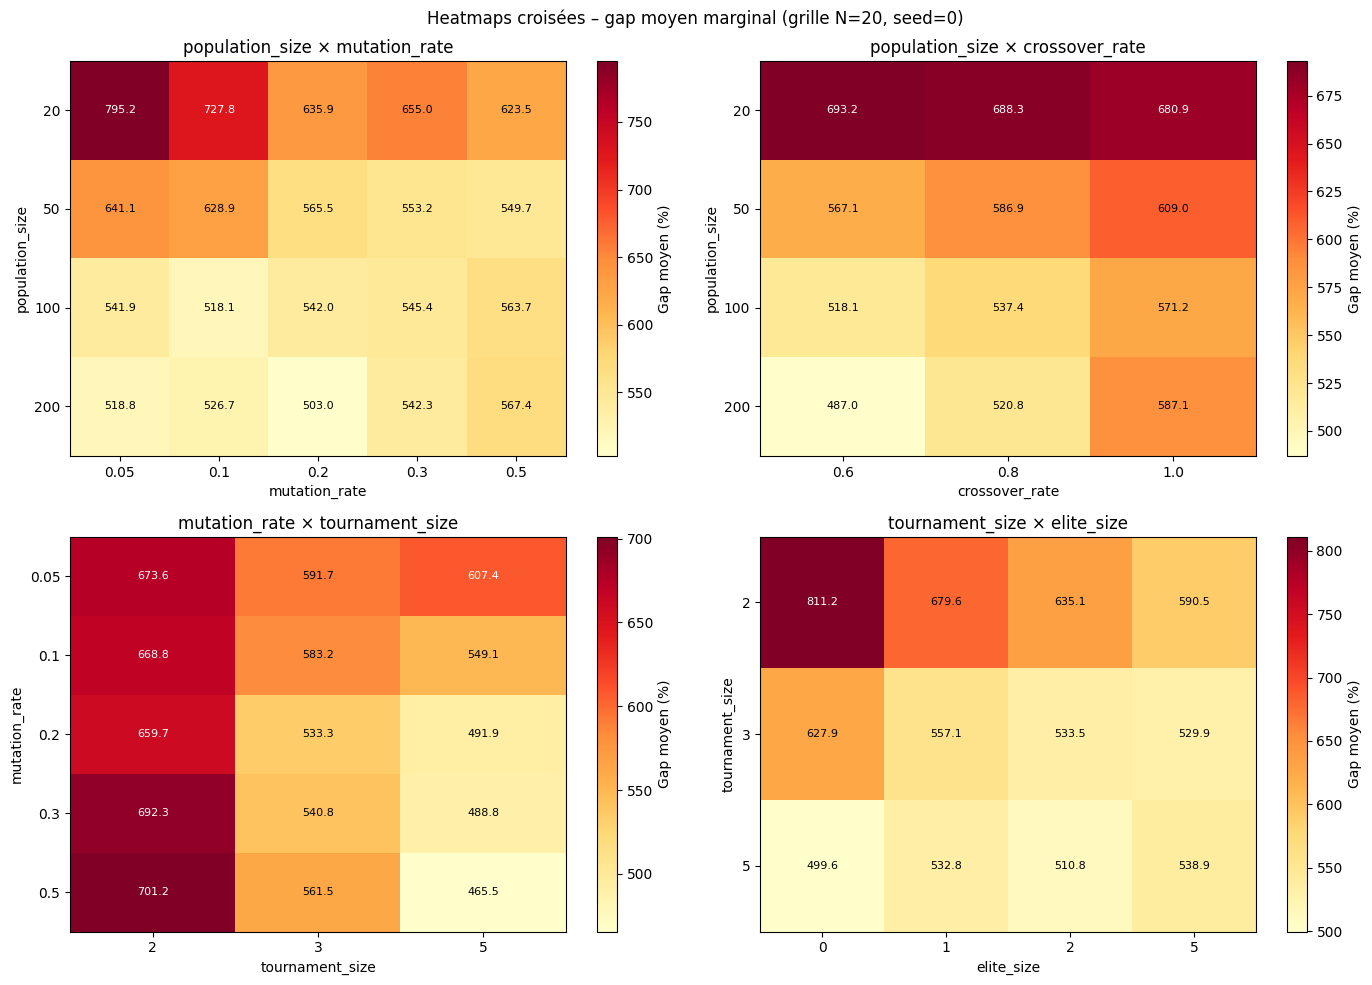

In [35]:
PARAM_NAMES = ["population_size", "crossover_rate", "mutation_rate", "tournament_size", "elite_size"]
PARAM_VALS  = [GRID_POP, GRID_CR, GRID_MR, GRID_TS, GRID_ES]

param_pairs = [(0, 2), (0, 1), (2, 3), (3, 4)]
pair_labels = [
    ("population_size", "mutation_rate"),
    ("population_size", "crossover_rate"),
    ("mutation_rate",   "tournament_size"),
    ("tournament_size", "elite_size"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (i, j), (label_i, label_j) in zip(axes.flat, param_pairs, pair_labels):
    vals_i = PARAM_VALS[i]
    vals_j = PARAM_VALS[j]
    matrix = np.zeros((len(vals_i), len(vals_j)))
    counts = np.zeros_like(matrix, dtype=int)

    for combo, gap in grid_results.items():
        vi = vals_i.index(combo[i])
        vj = vals_j.index(combo[j])
        matrix[vi, vj] += gap
        counts[vi, vj] += 1

    mean_matrix = matrix / np.where(counts > 0, counts, 1)

    im = ax.imshow(mean_matrix, cmap="YlOrRd", aspect="auto")
    plt.colorbar(im, ax=ax, label="Gap moyen (%)")

    ax.set_xticks(range(len(vals_j)))
    ax.set_xticklabels(vals_j)
    ax.set_yticks(range(len(vals_i)))
    ax.set_yticklabels(vals_i)
    ax.set_xlabel(label_j)
    ax.set_ylabel(label_i)
    ax.set_title(f"{label_i} × {label_j}")

    vmin, vmax = mean_matrix.min(), mean_matrix.max()
    for vi in range(len(vals_i)):
        for vj in range(len(vals_j)):
            val = mean_matrix[vi, vj]
            color = "white" if val > vmin + 0.6 * (vmax - vmin) else "black"
            ax.text(vj, vi, f"{val:.1f}", ha="center", va="center", fontsize=8, color=color)

plt.suptitle("Heatmaps croisées – gap moyen marginal (grille N=20, seed=0)")
plt.tight_layout()
plt.show()

## Distance à la borne (gap) par taille de graphe

On exécute l'algorithme génétique avec les paramètres par défaut (`generations=50`, `population_size=50`, `crossover_rate=0.8`, `mutation_rate=0.2`, `tournament_size=3`, `elite_size=2`) sur toutes les instances et on trace le gap en fonction de N.

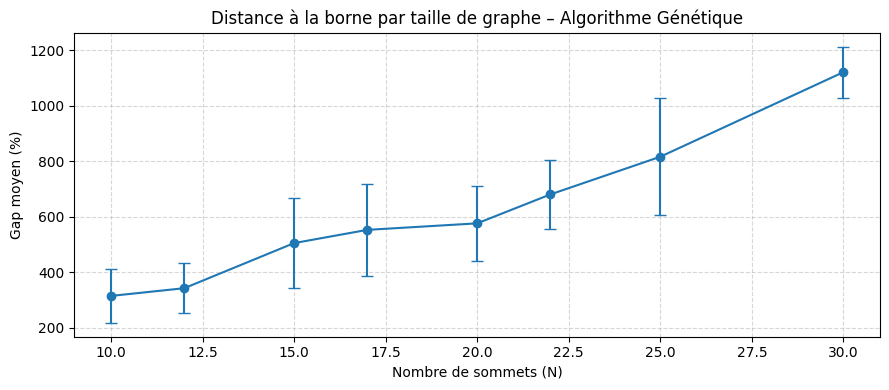

In [36]:
gap_by_n: dict[int, list[float]] = {}

for n in N_VALUES:
    gaps: list[float] = []
    for seed, graph, ref in instances[n]:
        _, cost = resolve_by_genetic(graph, generations=NB_GENERATIONS)
        gap = compute_gap(cost, ref)
        if not np.isnan(gap):
            gaps.append(gap)
    gap_by_n[n] = gaps

means = [np.mean(gap_by_n[n]) for n in N_VALUES]
stds  = [np.std(gap_by_n[n])  for n in N_VALUES]

plt.figure(figsize=(9, 4))
plt.errorbar(N_VALUES, means, yerr=stds, marker="o", capsize=4, linewidth=1.5)
plt.xlabel("Nombre de sommets (N)")
plt.ylabel("Gap moyen (%)")
plt.title("Distance à la borne par taille de graphe – Algorithme Génétique")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


## Statistiques descriptives

Tableau récapitulatif : meilleur coût, moyenne, médiane, écart-type, min et max — par taille de graphe.

In [37]:
rows: list[dict] = []
for n in N_VALUES:
    costs: list[float] = []
    for seed, graph, ref in instances[n]:
        _, cost = resolve_by_genetic(graph, generations=NB_GENERATIONS)
        if cost < PENALTY_COST:
            costs.append(cost)
    if not costs:
        continue
    gaps = [compute_gap(c, ref) for (_, __, ref), c in zip(instances[n], costs)]
    gaps = [g for g in gaps if not np.isnan(g)]
    rows.append({
        "N": n,
        "Meilleur": np.min(costs),
        "Moyenne": np.mean(costs),
        "Médiane": np.median(costs),
        "Écart-type": np.std(costs),
        "Min": np.min(costs),
        "Max": np.max(costs),
        "Gap moyen (%)": np.mean(gaps) if gaps else float("nan"),
    })

stats_df = pd.DataFrame(rows).set_index("N")
stats_df.round(3)

,Meilleur,Moyenne,Médiane,Écart-type,Min,Max,Gap moyen (%)
N,,,,,,,
10,37.35,48.605,46.950,8.106,37.35,63.75,334.457
12,42.75,56.835,50.100,13.072,42.75,83.50,375.636
15,45.85,63.085,61.425,10.887,45.85,82.55,484.111
17,54.60,63.565,58.800,9.729,54.60,81.00,499.671
20,47.25,73.655,73.525,16.669,47.25,100.80,563.119
22,49.80,81.320,78.450,16.984,49.80,105.50,696.392
25,58.80,94.815,93.375,15.938,58.80,125.25,778.933
30,106.20,123.360,124.800,8.148,106.20,133.35,1107.367


## Meilleurs paramètres

On identifie la combinaison `(population_size, crossover_rate, mutation_rate, tournament_size, elite_size)` qui minimise le gap sur l'instance N=20, seed=0 (grille complète).

In [38]:
best_combo_all = min(grid_results, key=grid_results.get)
best_gap_all   = grid_results[best_combo_all]
pop_size, cr, mr, ts, es = best_combo_all

print("Meilleurs paramètres (grille complète, N=20 seed=0) :")
print(f"  population_size = {pop_size}")
print(f"  crossover_rate  = {cr:.2f}")
print(f"  mutation_rate   = {mr:.2f}")
print(f"  tournament_size = {ts}")
print(f"  elite_size      = {es}")
print(f"  Gap             = {best_gap_all:.2f}%")

Meilleurs paramètres (grille complète, N=20 seed=0) :
  population_size = 50
  crossover_rate  = 1.00
  mutation_rate   = 0.50
  tournament_size = 5
  elite_size      = 2
  Gap             = 308.70%
